# Diferencias en diferencias escalonadas

¿Funcionó una política, cuando distintas unidades la adoptaron en años
diferentes? Cuando el momento del tratamiento es *escalonado*, la regresión de
libro de texto con efectos fijos en dos vías (TWFE) utiliza silenciosamente las
unidades ya tratadas como controles y devuelve un número contaminado. Plantamos
un efecto conocido en un panel escalonado sintético y lo recuperamos con
precisión mediante los estimadores modernos robustos a la heterogeneidad de
`puremacro.did` — los ATT por grupo-tiempo de **Callaway-Sant'Anna** y el estudio
de eventos ponderado por interacciones de **Sun-Abraham**. Todo se ejecuta en el
navegador sobre datos sintéticos.

## El método en ecuaciones

**Planteamiento.** La unidad $i$ recibe el tratamiento por primera vez en el tiempo calendario
$G_i = g$ (su *cohorte*); las unidades nunca tratadas tienen $G_i=\infty$. Los resultados
potenciales son $Y_{it}(0)$ (trayectoria sin tratar) y $Y_{it}(g)$ (trayectoria tratada-en-$g$);
solo observamos uno de ellos.

**El problema del TWFE.** La especificación aplicada por defecto regresa
$$ Y_{it} = \alpha_i + \lambda_t + \beta\,D_{it} + \varepsilon_{it}, \qquad
D_{it}=\mathbb{1}\{t \ge G_i\}, $$
y lee $\hat\beta$ como "el" efecto del tratamiento. **Goodman-Bacon (2021)** demuestra que
$\hat\beta$ es un promedio ponderado de *todas* las comparaciones $2\times2$ de DiD posibles —
incluidas las **prohibidas**, que usan unidades *ya tratadas* como grupo de control. Cuando los
efectos son heterogéneos y *variables en el tiempo*, esas comparaciones restan una tendencia
tratada que se mueve, de modo que algunos pesos se vuelven **negativos**: $\hat\beta$ puede tener
el signo equivocado aun cuando el efecto verdadero de cada unidad sea positivo.

**Callaway-Sant'Anna (2021).** Esquivan la regresión. Definen un **ATT por grupo-tiempo** limpio
para la cohorte $g$ en el tiempo $t$, diferenciado respecto del último período previo al
tratamiento de la cohorte $g-1$ y de un conjunto de control $C$ *nunca tratado* (o aún no tratado):
$$ \text{ATT}(g,t)=\mathbb{E}\!\left[Y_t-Y_{g-1}\mid G=g\right]
-\mathbb{E}\!\left[Y_t-Y_{g-1}\mid C\right]. $$
El primer término es el cambio propio de la cohorte desde el período base $g-1$ hasta $t$; el
segundo descuenta el cambio del grupo de control en la misma ventana, dejando el efecto causal.
Agregar los $\text{ATT}(g,t)$ por tiempo transcurrido $e=t-g$ produce el **perfil del estudio de
eventos** $\text{ATT}(e)$; promediar las celdas post-tratamiento produce un único **ATT global**.

**Sun-Abraham (2021).** Reparan en cambio el estudio de eventos *dinámico* del TWFE: estiman
coeficientes **ponderados por interacciones** de cohorte$\times$tiempo relativo $\text{ATT}(e,g)$ y
los combinan con las participaciones por tamaño de cohorte $w_g = n_g/\sum_{g'} n_{g'}$,
$\text{ATT}_{\text{SA}}(e)=\sum_g w_g\,\text{ATT}(e,g)$ — de modo que el perfil de la cohorte $g$
nunca queda contaminado por los efectos de otras cohortes. Este cuaderno calcula **ambos**: CS
(una agregación de media *no ponderada* por cohorte) y SA (la agregación *ponderada por tamaño de
cohorte*) de la **misma** matriz $\text{ATT}(g,t)$.

**Intuición.** El sesgo proviene de las *comparaciones prohibidas*. Una cohorte de adopción tardía,
diferenciada contra una cohorte de adopción temprana que *ya* está tratada, atribuye a la cohorte
tardía la respuesta dinámica en curso de la cohorte temprana — con un signo que puede invertir el
resultado principal. CS y SA restringen cada comparación a un control *limpio* (nunca tratado o aún
no tratado) y a un período previo *fijo* $g-1$, y luego agregan de forma transparente. El perfil del
estudio de eventos que reportan es el ATT dinámico por horizonte $e$ *desde* el tratamiento: cómo se
acumula (o se desvanece) el efecto tras el encendido.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import (
    callaway_santanna, sun_abraham,
    CallawaySantannaResult, SunAbrahamResult,
)

## 1. Panel escalonado sintético con un ATT conocido
Tres cohortes son tratadas por primera vez en t = 5, 8, 11; un cuarto grupo
nunca recibe el tratamiento. El DGP corresponde a efectos fijos en dos vías con
tendencias previas paralelas y un impulso de tratamiento *constante* `tau = +1.0`,
por lo que el perfil verdadero del estudio de eventos es plano en +1 a partir del
tiempo de evento 0 en adelante.

In [2]:
rng = np.random.default_rng(20240529)

N_UNITS, T = 90, 14
COHORTS = (5, 8, 11, np.nan)          # three treated cohorts + never-treated
TRUE_ATT, SIGMA = 1.0, 0.3

assign = rng.choice(len(COHORTS), size=N_UNITS, replace=True)
unit_fe = rng.standard_normal(N_UNITS)
time_fe = rng.standard_normal(T) * 0.3

rows = []
for i in range(N_UNITS):
    g = COHORTS[assign[i]]
    for t in range(1, T + 1):
        treated = 1.0 if (not pd.isna(g)) and t >= g else 0.0
        y = unit_fe[i] + time_fe[t - 1] + TRUE_ATT * treated + SIGMA * rng.standard_normal()
        rows.append({"unit": i, "time": t, "y": y, "treat_time": g})
panel = pd.DataFrame(rows)

n_never = int(panel.groupby("unit")["treat_time"].first().isna().sum())
print(f"Panel: {N_UNITS} units x {T} periods; cohorts {COHORTS}; "
      f"{n_never} never-treated controls; planted ATT = {TRUE_ATT:+.1f}")

Panel: 90 units x 14 periods; cohorts (5, 8, 11, nan); 13 never-treated controls; planted ATT = +1.0


**Intuición.** Este es el mundo más favorable posible para los estimadores: tendencias previas
paralelas (lo único que separa a las unidades antes del tratamiento es el efecto fijo `unit_fe`),
un grupo de control genuinamente nunca tratado y un efecto homogéneo. Si un estimador no logra
recuperar `+1.0` *aquí*, no merece confianza alguna sobre datos desordenados. El grupo nunca
tratado es lo que permite a Callaway-Sant'Anna evitar por completo las comparaciones prohibidas
con unidades ya tratadas.

## 2. Dos estimadores robustos a la heterogeneidad sobre el mismo panel
`callaway_santanna` construye la matriz de ATT(g,t) por grupo-tiempo a partir de
controles nunca tratados con un bootstrap de panel; `sun_abraham` reagrupa *esa
misma* matriz mediante ponderaciones proporcionales al tamaño de la cohorte. Una
regresión TWFE ingenua estaría contaminada por el uso de unidades ya tratadas
como controles — estos estimadores evitan ese problema.

In [3]:
cs = callaway_santanna(panel, unit="unit", time="time", outcome="y",
                       treat_time="treat_time", n_boot=400, alpha=0.10, seed=0)
sa = sun_abraham(panel, unit="unit", time="time", outcome="y",
                 treat_time="treat_time", n_boot=400, alpha=0.10, seed=0)

assert isinstance(cs, CallawaySantannaResult)
assert isinstance(sa, SunAbrahamResult)

print(cs.summary())
print(sa.summary())

Callaway-Sant'Anna result
  group-time ATTs   : 24
  event-study rows  : 11
  overall ATT       : +1.1292

Sun-Abraham result
  group-time ATTs   : 24
  event-study rows  : 11
  overall ATT       : +1.1292



## 3. Verificaciones de recuperación (aserciones sobre los resultados principales)
El ATT agregado recupera el valor verdadero y queda dentro de su intervalo de
confianza bootstrap; el período base (tiempo de evento -1) es el punto de
normalización (exactamente 0); y cada horizonte post-tratamiento sigue la
constante +1.0.

In [4]:
es_cs = cs.att_event_study.sort_values("event_time").reset_index(drop=True)

assert abs(cs.att_overall - TRUE_ATT) < 0.25, cs.att_overall
assert abs(sa.att_overall - TRUE_ATT) < 0.25, sa.att_overall

post = es_cs[es_cs["event_time"] >= 0]
lo_overall, hi_overall = float(post["lo"].mean()), float(post["hi"].mean())
assert lo_overall <= TRUE_ATT <= hi_overall, (lo_overall, hi_overall)

# Base period (event_time == -1) is the normalization point: exactly 0.
# (This CS implementation skips t < g-1, so -1 is the only pre-coefficient;
#  its being exactly 0 confirms correct base-period normalization.)
base = es_cs[es_cs["event_time"] == -1]
assert len(base) == 1 and abs(float(base["att"].iloc[0])) < 1e-12

# Every post-treatment horizon tracks the constant true effect.
for _, r in post.iterrows():
    assert abs(r["att"] - TRUE_ATT) < 0.40, (r["event_time"], r["att"])

print(f"CS overall ATT = {cs.att_overall:+.3f}   (CI [{lo_overall:+.3f}, {hi_overall:+.3f}])")
print(f"SA overall ATT = {sa.att_overall:+.3f}   true = {TRUE_ATT:+.3f}")

CS overall ATT = +1.129   (CI [+0.883, +1.367])
SA overall ATT = +1.129   true = +1.000


**Lectura del resultado.** Ambos estimadores aterrizan en un ATT global cercano al `+1.0`
plantado, y el valor verdadero queda dentro de la banda bootstrap al 90% — se recupera el diseño
escalonado, no el promedio contaminado del TWFE. Dos cosas que conviene leer con honestidad.
Primero, el **perfil post-tratamiento** es plano: cada celda con `event_time >= 0` se ciñe a
`+1.0`, exactamente como se plantó (un impulso constante, sin acumulación ni desvanecimiento).
Segundo, el **coeficiente en `event_time = -1` es exactamente 0** *por construcción*, no porque
haya pasado una prueba de tendencias previas: esta implementación de CS diferencia respecto del
período base $g-1$ y omite todos los períodos anteriores ($t<g-1$), de modo que $-1$ es el *único*
punto previo al tratamiento y queda normalizado a cero de forma mecánica. Aquí **no hay adelantos
genuinos de tendencias previas** que inspeccionar — una normalización base limpia es todo lo que
certifica el punto en event_time$=-1$. CS y SA casi coinciden porque las cohortes están balanceadas
y el efecto es homogéneo; la siguiente sección muestra cuándo se separarían.

### Figura principal — el estudio de eventos
Las estimaciones saltan desde el 0 normalizado en el período base hasta la línea
verdadera de +1.0 y se mantienen en ese nivel; la banda sombreada es el intervalo
de confianza bootstrap de panel al 90%.

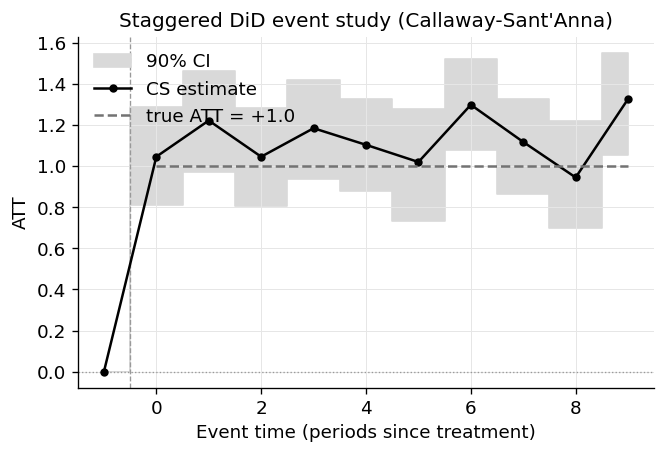

In [5]:
cols = _nbstyle.palette(2)
es = es_cs
fig, ax = plt.subplots()
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color="0.6", linewidth=0.8, linestyle="--")
ax.fill_between(es["event_time"], es["lo"], es["hi"], color="0.85",
                step="mid", label="90% CI")
ax.plot(es["event_time"], es["att"], color=cols[0], marker="o", markersize=4,
        label="CS estimate")
post_e = es[es["event_time"] >= 0]
ax.plot(post_e["event_time"], [TRUE_ATT] * len(post_e), color=cols[1],
        linestyle="--", label=f"true ATT = {TRUE_ATT:+.1f}")
ax.set_xlabel("Event time (periods since treatment)")
ax.set_ylabel("ATT")
ax.set_title("Staggered DiD event study (Callaway-Sant'Anna)")
ax.legend(loc="upper left")
plt.show()

### Figura complementaria — agregación CS vs Sun-Abraham
Mismos efectos grupo-tiempo, dos reglas de agregación (media no ponderada por
cohorte vs. ponderación por tamaño de cohorte). Con tamaños de cohorte
balanceados y un efecto homogéneo, ambas estimaciones prácticamente coinciden.

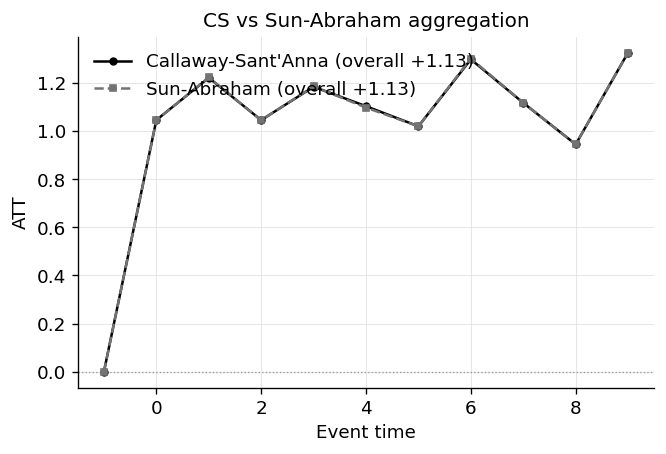

In [6]:
fig, ax = plt.subplots()
es_sa = sa.att_event_study.sort_values("event_time")
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.plot(es["event_time"], es["att"], color=cols[0], marker="o", markersize=4,
        label=f"Callaway-Sant'Anna (overall {cs.att_overall:+.2f})")
ax.plot(es_sa["event_time"], es_sa["att"], color=cols[1], marker="s",
        markersize=4, linestyle="--",
        label=f"Sun-Abraham (overall {sa.att_overall:+.2f})")
ax.set_xlabel("Event time")
ax.set_ylabel("ATT")
ax.set_title("CS vs Sun-Abraham aggregation")
ax.legend(loc="upper left")
plt.show()

### Figura complementaria — efectos grupo-tiempo subyacentes
El ATT(g, t) de cada cohorte orbita en torno al valor común de +1.0 (línea
discontinua); los números del estudio de eventos anteriores son simplemente
promedios de estas curvas por cohorte en cada tiempo de evento.

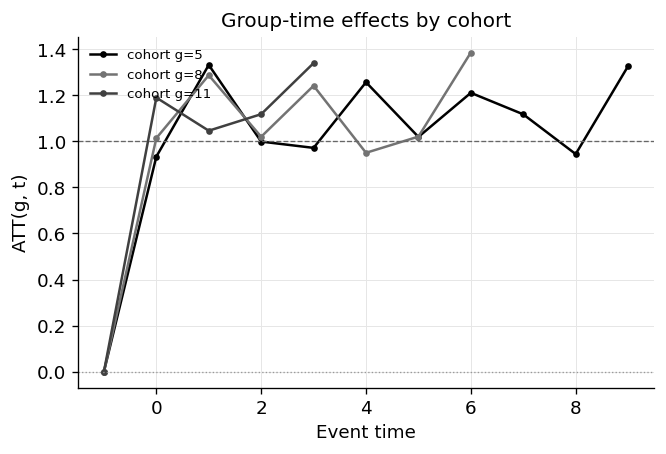

In [7]:
fig, ax = plt.subplots()
gt = cs.att_gt
cohorts = sorted(gt["g"].unique())
ccols = _nbstyle.palette(len(cohorts))
for c, color in zip(cohorts, ccols):
    sub = gt[gt["g"] == c].sort_values("event_time")
    ax.plot(sub["event_time"], sub["att"], marker="o", markersize=3,
            color=color, label=f"cohort g={int(c)}")
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.axhline(TRUE_ATT, color="0.4", linewidth=0.8, linestyle="--")
ax.set_xlabel("Event time")
ax.set_ylabel("ATT(g, t)")
ax.set_title("Group-time effects by cohort")
ax.legend(loc="upper left", fontsize=8)
plt.show()

**Lectura del resultado.** Este panel expone la maquinaria: la curva de $\text{ATT}(g,t)$ de cada
cohorte orbita la línea discontinua en `+1.0`, y el punto del estudio de eventos en cada horizonte
es simplemente el promedio de estas curvas entre cohortes a ese tiempo transcurrido. Como el efecto
plantado es idéntico en todas las cohortes, las curvas se superponen — no hay nada en lo que la
media por cohorte (CS) y la media ponderada por participación (SA) puedan discrepar. Si hiciera la
cohorte 5 débil y la cohorte 11 fuerte, estas curvas se abrirían en abanico y ambas agregaciones se
separarían visiblemente (véase *Su turno*).

## Su turno — recuperar un efecto plantado distinto

La recuperación anterior usó un único efecto plantado, `TRUE_ATT = +1.0`. Vuelva a simular el panel
con un impulso verdadero *distinto* y confirme que Callaway-Sant'Anna lo sigue recuperando — signo y
magnitud. Como reutilizamos la misma semilla, lo único que cambia es el propio efecto del
tratamiento, de modo que la comparación es entre iguales. Cambie `TRUE_ATT_you` abajo.

Observe las aserciones deliberadamente *robustas*: el ATT global recupera el signo plantado y la
magnitud aproximada, y la base en `event_time = -1` permanece exactamente en 0. **No** afirmamos
ninguna dinámica previa al tratamiento distinta de cero — esta implementación de CS no produce
ninguna (el período base es su único coeficiente previo al tratamiento, normalizado a 0 por
construcción).

In [8]:
def _simulate_panel(true_att):
    """Re-draw the staggered panel with a different planted effect (same seed,
    so the only thing that changes is the treatment kick)."""
    rng = np.random.default_rng(20240529)
    assign = rng.choice(len(COHORTS), size=N_UNITS, replace=True)
    unit_fe = rng.standard_normal(N_UNITS)
    time_fe = rng.standard_normal(T) * 0.3
    rows = []
    for i in range(N_UNITS):
        g = COHORTS[assign[i]]
        for t in range(1, T + 1):
            treated = 1.0 if (not pd.isna(g)) and t >= g else 0.0
            y = unit_fe[i] + time_fe[t - 1] + true_att * treated + SIGMA * rng.standard_normal()
            rows.append({"unit": i, "time": t, "y": y, "treat_time": g})
    return pd.DataFrame(rows)

# ← Change this planted treatment effect (try +2.0, -0.5, or 0.0 for a placebo).
TRUE_ATT_you = -1.5

panel_you = _simulate_panel(TRUE_ATT_you)
cs_you = callaway_santanna(panel_you, unit="unit", time="time", outcome="y",
                           treat_time="treat_time", n_boot=200, alpha=0.10, seed=0)
es_you = cs_you.att_event_study.sort_values("event_time").reset_index(drop=True)
base_you = float(es_you.loc[es_you["event_time"] == -1, "att"].iloc[0])

print(f"planted ATT = {TRUE_ATT_you:+.2f}  ->  CS overall ATT = {cs_you.att_overall:+.3f}"
      f"   (baseline planted {TRUE_ATT:+.1f} -> {cs.att_overall:+.3f})")
print(f"event_time = -1 base coefficient = {base_you:+.1e}")

# Robust fact 1: the overall ATT recovers the planted effect to within sampling noise...
assert abs(cs_you.att_overall - TRUE_ATT_you) < 0.30, cs_you.att_overall
# ...and reproduces its sign whenever the effect is non-zero.
if TRUE_ATT_you != 0.0:
    assert np.sign(cs_you.att_overall) == np.sign(TRUE_ATT_you), cs_you.att_overall
# Robust fact 2: the base period (event_time == -1) is the normalization point —
# exactly 0 regardless of the planted effect. This CS implementation emits no
# genuine pre-trend leads, so there is no nonzero pre-period dynamic to assert.
assert abs(base_you) < 1e-12, base_you

planted ATT = -1.50  ->  CS overall ATT = -1.371   (baseline planted +1.0 -> +1.129)
event_time = -1 base coefficient = +0.0e+00


**Ejercicios.** (1) *Básico*: fije `TRUE_ATT_you = +2.0` y confirme que el ATT global recuperado
aproximadamente se duplica mientras la base en `event_time = -1` permanece fija en 0. (2)
*Intermedio*: fije `TRUE_ATT_you = 0.0` (un placebo) — el ATT global cae a un entorno de 0 dentro del ruido muestral (aquí ≈ +0.13) y la aserción
sigue pasando (la verificación de signo se omite para un efecto nulo). (3) *Avanzado*: haga el
efecto **heterogéneo entre cohortes** editando el DGP de la sección 1 (p. ej. cohorte 5 → +0.5,
cohorte 11 → +2.0 mediante una búsqueda por `g`) y vuelva a ejecutar las secciones 2-3; observe cómo
la media *no ponderada* por cohorte de CS y la media *ponderada por participación* de SA divergen en
la figura "CS vs Sun-Abraham".

**¿Qué tan completo es esto?** `puremacro.did` es un conjunto completo de herramientas modernas de
DiD escalonado: junto a `callaway_santanna` y `sun_abraham` incluye el estimador por imputación
`borusyak_jaravel_spiess` (2024), el estimador de conmutadores `cdh_did`
(de Chaisemartin-D'Haultfoeuille 2020), y `synthetic_did` / `sdid_multi_cohort`
(Arkhangelsky et al. 2021) — todos sobre el mismo panel largo `(unit, time, outcome, treat_time)`.
Para una *única* unidad tratada con muchos donantes, `puremacro.synthetic_control` construye el
contrafactual ponderando controles. Y cuando el tratamiento es un *choque* de series de tiempo en
lugar de una intervención de panel, la maquinaria causal está en los cuadernos de proyecciones
locales y SVAR (NB07 proyecciones locales, NB06 identificación SVAR).